# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


The stages at which sampling is occurring in the model is:
1. Building the population.
Before any randomness, the code sets up a sampling frame of 1000 people where 200 are labelled `wedding` and 800 are labelled `brunch`. This defines the population that every later step draws from.
2. Picking who gets infected
```
infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
```
uses `np.random.choice` and takes a random sample without replacement of 100 people (10% of 1000, `ATACK_RATE= 0.10`) out of the full population. This is the same as drawing from a discrete uniform distribution over the 1000 indices and the sample size is fixed at 100.
3. Primary contact tracing.
```
ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS
```
only samples from the approx. 100 infected people as the sampling frame here is smaller and for each infected person, it draws a uniform [0,1] random number with `np.random.rand` and marks them traced if the number is below `TRACE_SUCCESS=0.20`. This is a **Bernouilli(0.20)** trial per person, so the total number of primary traces follows a **Binomial(n=100,p=0.20)** distribution with an expected value of 20. The sample size is random here rather than Fixed.
4. Repeats the simulation
```
results = [simulate_event(m) for m in range(1000)]
```
reruns the whole siulation 1000 times which is a Monte Carlo step. Each replicate is one drwa from the distribution of outcomes produced by steps 2 and 3, and the 1000 results together approximate the sampling distribution of the two proportions (`p_wedding_infections` and `p_wedding_traces`). The secondary contact tracing step (which bumps everyone up at an event up to traced if at least 2 people were already traced) is deterministic and is not sampling applied on step 3 which is what causes the wedding bias that the assignment highlights because a smaller event with the same per-person tracing probability is more likely to cross the threshold.

However, none of these random steps sets a seed which is an issue for reproducibility.


Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

I changed `range(1000)` in `results = [simulate_event(m) for m in range(1000)]` to `range(10)` and `range(100)` and ran the cell several times for each.

With 10 repetitions, the histograms looks very different each time I ran the cell. Sometimes, the blue (infections from weddings) bars sat around 0.20, 0.15 or 0.25. The red bars (traces to weddings) jumped around more. It was almost impossible to see a stable pattern or to tell if the two distributions actually differed.

With 100 repetitions, the shapes were more consistent. Across runs the blue bars were mostly around 0.20 and the red bars were mostly around 0.15, but there was still a lot of variability in the heights of the bars across runs. It was easier to see that the two distributions differed but it was still hard to say how much they differed or to be confident in the exact values of the proportions.

With 1000 repetitions, the histograms were the same every time I ran the cell. Blue stayed tightly centered around 0.20, red stayed centered above it and the overall shape of both distributions barely changed across runs.

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

1. Added a fixed seed constant `SEED = 42` at top so it is easy to find and change.
2. Switched to explicit rng object instead of relying on NumPy's global random state, created `rng = np.random_default_rng(SEED)` and passed it to `simulate_event`. Inside the function, the calls became `rng.choice(...)` and `rng.random(...)`. Other code which uses `np.random` cannot accidentally consume numbers or be affected from my seed.
3. Re-seeded the RNG before each panel. Created a fresh `rng = np.random_default_rng(SEED)` inside the `fior ax, n_reps in zip(axes, n_reps_list)` loop. This way, the n=10 panel uses teh first 10 simulations of the seeded stream and the n=100 panel uses the first 100 simulations of the same stream, and the n=1000 panel uses the first 1000. So, the n=10 panel is just a "zoomed-in" version of the first 10 reps inside the n=100 panel, which makes the three plots directly comparable.

## Code

### Original Code

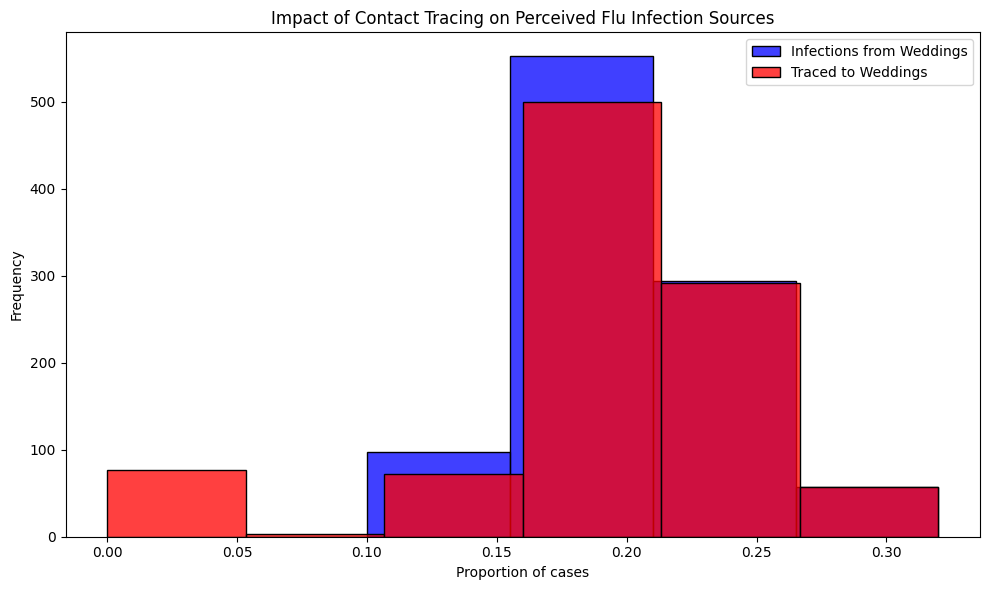

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

def simulate_event(m):
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """
  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# Run the simulation 1000 times
results = [simulate_event(m) for m in range(1000)]
props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

### Modified Code - Number of Repetitions

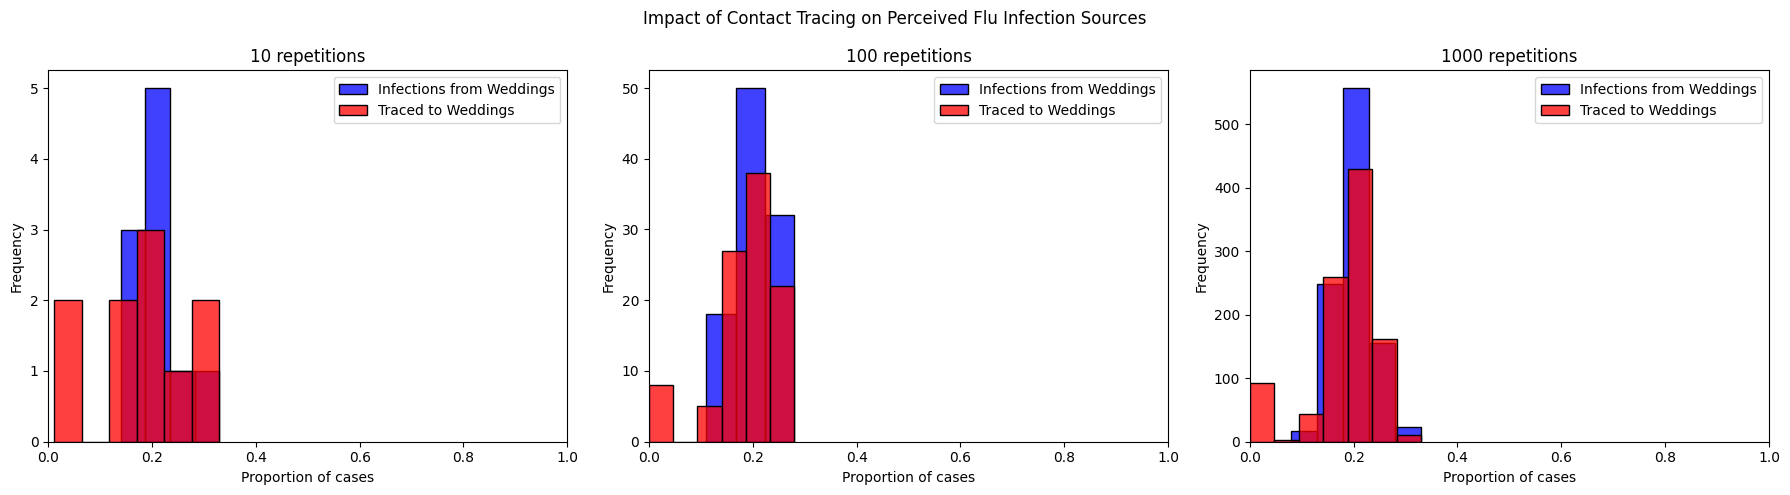

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

def simulate_event(m):
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan
  })
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  ppl['event_type'] = ppl['event'].str[0]
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# Run the simulation at three different sample sizes and plot side by side
n_reps_list = [10, 100, 1000]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, n_reps in zip(axes, n_reps_list):
    results = [simulate_event(m) for m in range(n_reps)]
    props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

    sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05,
                 kde=False, label='Infections from Weddings', ax=ax)
    sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05,
                 kde=False, label='Traced to Weddings', ax=ax)
    ax.set_xlabel("Proportion of cases")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{n_reps} repetitions")
    ax.set_xlim(0, 1)
    ax.legend()

fig.suptitle("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.tight_layout()
plt.show()

### Modified Code - Reproducibility

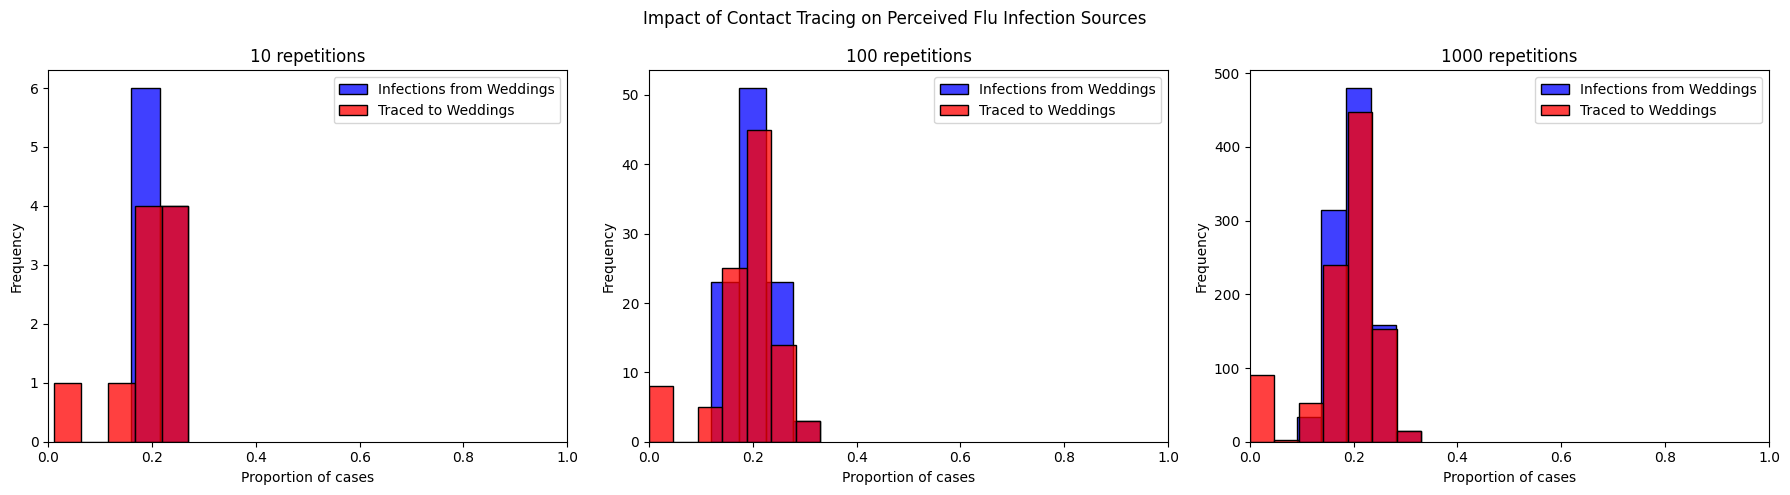

In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2
SEED = 42  # <-- fixed seed for reproducibility

def simulate_event(m, rng):
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan
  })
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Use the passed-in rng instead of the global np.random
  infected_indices = rng.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  ppl.loc[ppl['infected'], 'traced'] = rng.random(sum(ppl['infected'])) < TRACE_SUCCESS

  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  ppl['event_type'] = ppl['event'].str[0]
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# Run the simulation at three different sample sizes and plot side by side
n_reps_list = [10, 100, 1000]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, n_reps in zip(axes, n_reps_list):
    rng = np.random.default_rng(SEED)  # <-- fresh seeded rng per panel
    results = [simulate_event(m, rng) for m in range(n_reps)]
    props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

    sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05,
                 kde=False, label='Infections from Weddings', ax=ax)
    sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05,
                 kde=False, label='Traced to Weddings', ax=ax)
    ax.set_xlabel("Proportion of cases")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{n_reps} repetitions")
    ax.set_xlim(0, 1)
    ax.legend()

fig.suptitle("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.tight_layout()
plt.show()

## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 02 February 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
